# Exploratory Data Analysis — Chapter 4.3

This notebook produces the EDA figures for the thesis (Chapter 4, Section 4.3).
It replicates the preprocessing from Paper 1's `generating_explanations.ipynb` and creates:

1. **Figure 4.1** — Weekly consumption time series with train/test split
2. **Figure 4.2** — Target variable distribution
3. **Figure 4.3** — Feature correlation heatmap
4. **Figure 4.4** — Seasonal decomposition
5. **Figure 4.5** — ACF and PACF
6. **Figure 4.6** — Box plot (outlier analysis)
7. **Stationarity test** — Augmented Dickey-Fuller

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from pathlib import Path
import holidays

# Plotting defaults
plt.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.figsize': (10, 4),
    'axes.spines.top': False,
    'axes.spines.right': False,
})

DATA_PATH = Path('../../data/household_power_consumption.txt')
FIG_DIR = Path('../../Thesis_latex/figures/figures_ch4')
FIG_DIR.mkdir(parents=True, exist_ok=True)

## 1. Load and preprocess

Replicates the preprocessing from Paper 1: read raw minute-level data, interpolate missing values, convert kW to kWh, aggregate to weekly (Monday-anchored), engineer lag and calendar features.

In [2]:
# --- Load raw data ---
df = pd.read_csv(DATA_PATH, sep=';', dayfirst=True, na_values='?', low_memory=False)
df['DateTime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], dayfirst=True)
df.set_index('DateTime', inplace=True)

print(f'Raw records: {len(df):,}')
print(f'Missing values: {df["Global_active_power"].isna().sum():,} ({df["Global_active_power"].isna().mean():.2%})')
print(f'Date range: {df.index.min()} to {df.index.max()}')

Raw records: 2,075,259
Missing values: 25,979 (1.25%)
Date range: 2006-12-16 17:24:00 to 2010-11-26 21:02:00


In [3]:
# --- Interpolate missing values & convert kW to kWh ---
df['Global_active_power'] = df['Global_active_power'].astype(float).interpolate() * (1 / 60)

# --- Weekly aggregation (Monday anchor, ISO week alignment) ---
w = (
    df['Global_active_power']
    .resample('W-MON')
    .sum()
    .to_frame('True_Value')
    .reset_index()
)

# ISO week number
w['weekofyear'] = w['DateTime'].dt.isocalendar().week.astype(int)

# Holiday count per week
fr_hols = holidays.CountryHoliday('FR')

def holiday_count(week_end):
    wk_start = week_end - pd.Timedelta(days=6)
    return sum(1 for d in pd.date_range(wk_start, week_end) if d in fr_hols)

w['holiday_week_count'] = w['DateTime'].apply(holiday_count)

# Lag features
for k in range(1, 8):
    w[f'lag_{k}'] = w['True_Value'].shift(k)

w.dropna(inplace=True)
w.reset_index(drop=True, inplace=True)

# Feature column list
feature_cols = [f'lag_{k}' for k in range(1, 8)] + ['weekofyear', 'holiday_week_count']

print(f'Weekly observations: {len(w)}')
print(f'Date range: {w["DateTime"].min().date()} to {w["DateTime"].max().date()}')
w.head()

Weekly observations: 200
Date range: 2007-02-05 to 2010-11-29


,DateTime,True_Value,weekofyear,holiday_week_count,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7
0,2007-02-05,280.583133,6,0,251.649517,275.958033,268.114417,240.890400,329.257267,300.281867,113.391033
1,2007-02-12,255.021267,7,0,280.583133,251.649517,275.958033,268.114417,240.890400,329.257267,300.281867
2,2007-02-19,261.573000,8,0,255.021267,280.583133,251.649517,275.958033,268.114417,240.890400,329.257267
3,2007-02-26,194.980800,9,0,261.573000,255.021267,280.583133,251.649517,275.958033,268.114417,240.890400
4,2007-03-05,127.371533,10,0,194.980800,261.573000,255.021267,280.583133,251.649517,275.958033,268.114417


In [4]:
# --- Train/test split (chronological 70/30) ---
TRAIN_FRAC = 0.70
split_idx = int(len(w) * TRAIN_FRAC)

train = w.iloc[:split_idx]
test = w.iloc[split_idx:]

split_date = w.iloc[split_idx]['DateTime']
print(f'Train: {len(train)} obs ({train["DateTime"].min().date()} to {train["DateTime"].max().date()})')
print(f'Test:  {len(test)} obs ({test["DateTime"].min().date()} to {test["DateTime"].max().date()})')
print(f'Split date: {split_date.date()}')

Train: 140 obs (2007-02-05 to 2009-10-05)
Test:  60 obs (2009-10-12 to 2010-11-29)
Split date: 2009-10-12


## 2. Descriptive statistics

In [5]:
# Summary statistics for the target and selected features (train vs test)
feature_cols_short = ['True_Value', 'lag_1', 'lag_2', 'lag_7', 'weekofyear', 'holiday_week_count']

stats = []
for name, df_ in [('Train', train), ('Test', test)]:
    for c in feature_cols_short:
        stats.append({
            'Split': name,
            'Feature': c,
            'Mean': df_[c].mean(),
            'SD': df_[c].std(),
            'Min': df_[c].min(),
            'Max': df_[c].max(),
        })

desc = pd.DataFrame(stats).set_index(['Feature', 'Split']).unstack('Split')
desc = desc.swaplevel(axis=1).sort_index(axis=1, level=0, sort_remaining=False)
desc = desc[['Train', 'Test']]
desc.round(2)

Split                Train                          Test                      
                      Mean     SD    Min     Max    Mean     SD    Min     Max
Feature                                                                       
True_Value          177.53  54.40  30.52  316.58  184.61  45.06  63.46  273.28
holiday_week_count    0.19   0.41   0.00    2.00    0.22   0.42   0.00    1.00
lag_1               178.14  54.75  30.52  316.58  185.63  43.90  63.46  273.28
lag_2               178.95  55.35  30.52  316.58  185.16  43.99  63.46  273.28
lag_7               182.42  58.26  30.52  329.26  181.26  44.70  63.46  273.28
weekofyear           25.73  14.08   1.00   52.00   29.10  15.64   1.00   53.00

## 3. Figure 4.1 — Weekly consumption time series with train/test split

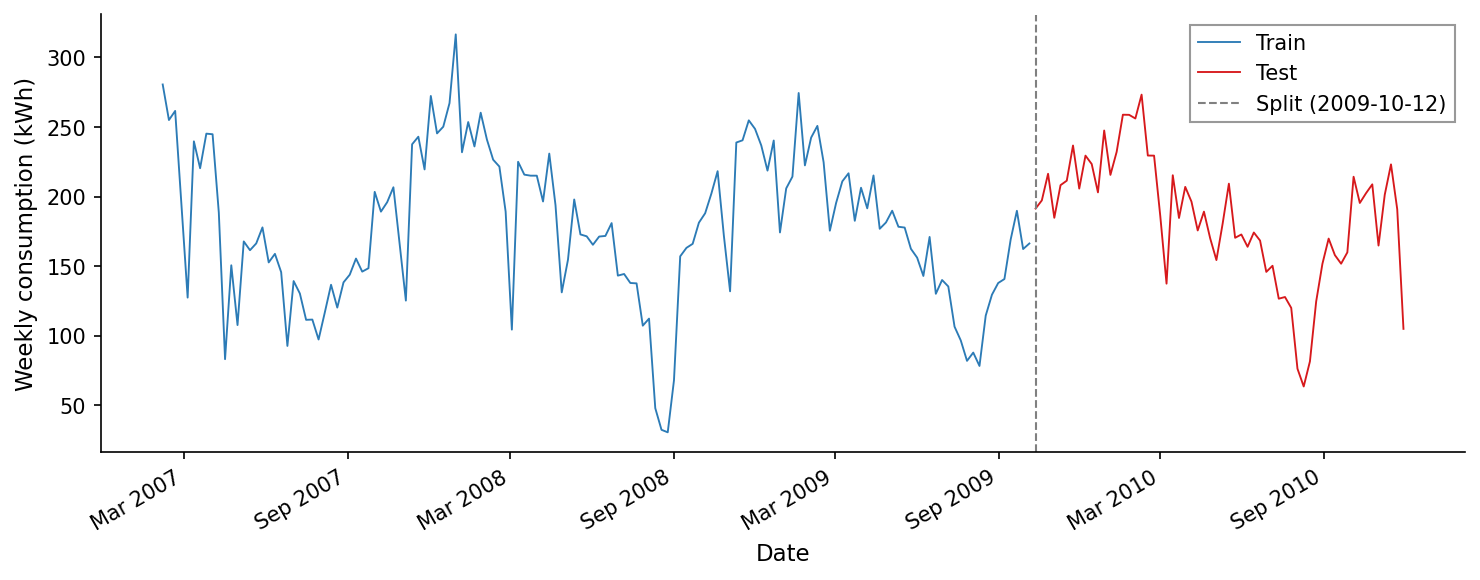

In [6]:
fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(train['DateTime'], train['True_Value'], color='#2c7bb6', linewidth=0.9, label='Train')
ax.plot(test['DateTime'], test['True_Value'], color='#d7191c', linewidth=0.9, label='Test')
ax.axvline(split_date, color='grey', linestyle='--', linewidth=1, label=f'Split ({split_date.date()})')

ax.set_xlabel('Date')
ax.set_ylabel('Weekly consumption (kWh)')
ax.legend(loc='upper right', frameon=True, fancybox=False, edgecolor='grey')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
fig.autofmt_xdate(rotation=30)

plt.tight_layout()
fig.savefig(FIG_DIR / 'fig_4_1_weekly_timeseries.pdf', bbox_inches='tight')
plt.show()

## 4. Figure 4.2 — Target variable distribution

## 4a. Figure — Holiday week count distribution

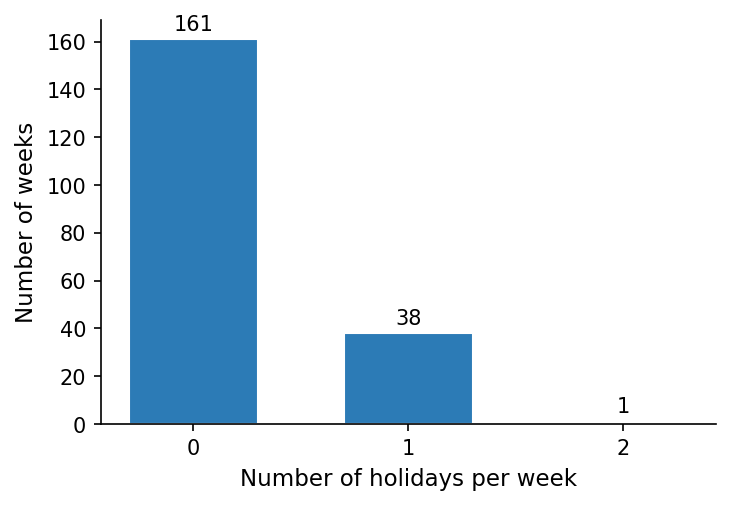

In [7]:
counts = w['holiday_week_count'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(5, 3.5))
bars = ax.bar(counts.index, counts.values, color='#2c7bb6', edgecolor='white', width=0.6)

# Add count labels on top of each bar
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2,
            str(val), ha='center', va='bottom', fontsize=10)

ax.set_xlabel('Number of holidays per week')
ax.set_ylabel('Number of weeks')
ax.set_xticks(counts.index)

plt.tight_layout()
fig.savefig(FIG_DIR / 'fig_4_holiday_count.pdf', bbox_inches='tight')
plt.show()

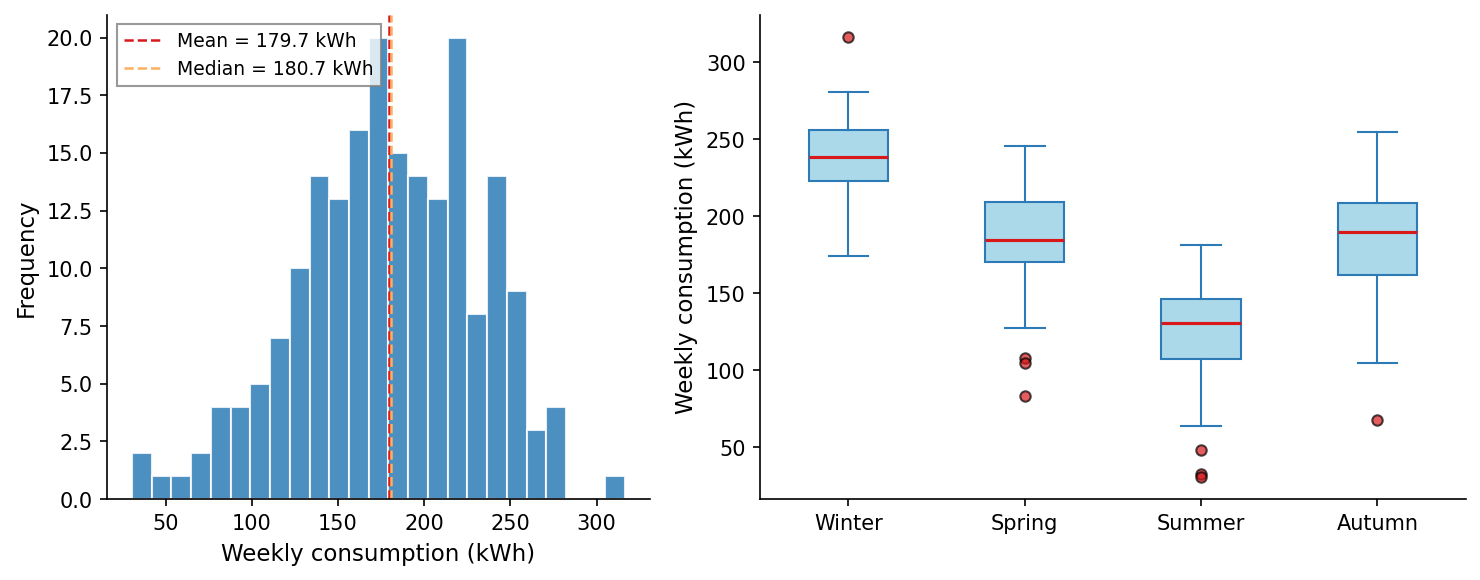

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4), gridspec_kw={'width_ratios': [1, 1.3]})

# Left: histogram
ax1.hist(w['True_Value'], bins=25, color='#2c7bb6', edgecolor='white', alpha=0.85)
ax1.axvline(w['True_Value'].mean(), color='#d7191c', linestyle='--', linewidth=1.2,
           label=f'Mean = {w["True_Value"].mean():.1f} kWh')
ax1.axvline(w['True_Value'].median(), color='#fdae61', linestyle='--', linewidth=1.2,
           label=f'Median = {w["True_Value"].median():.1f} kWh')
ax1.set_xlabel('Weekly consumption (kWh)')
ax1.set_ylabel('Frequency')
ax1.legend(frameon=True, fancybox=False, edgecolor='grey', fontsize=9)

# Right: box plots by season
w['season'] = w['DateTime'].dt.month.map(
    {12: 'Winter', 1: 'Winter', 2: 'Winter',
     3: 'Spring', 4: 'Spring', 5: 'Spring',
     6: 'Summer', 7: 'Summer', 8: 'Summer',
     9: 'Autumn', 10: 'Autumn', 11: 'Autumn'})
season_order = ['Winter', 'Spring', 'Summer', 'Autumn']
data_by_season = [w[w['season'] == s]['True_Value'].values for s in season_order]

bp = ax2.boxplot(data_by_season, vert=True, patch_artist=True,
                 boxprops=dict(facecolor='#abd9e9', edgecolor='#2c7bb6'),
                 medianprops=dict(color='#d7191c', linewidth=1.5),
                 whiskerprops=dict(color='#2c7bb6'),
                 capprops=dict(color='#2c7bb6'),
                 flierprops=dict(marker='o', markerfacecolor='#d7191c', markersize=5, alpha=0.7))
ax2.set_xticklabels(season_order)
ax2.set_ylabel('Weekly consumption (kWh)')

plt.tight_layout()
fig.savefig(FIG_DIR / 'fig_4_2_target_distribution.pdf', bbox_inches='tight')
plt.show()

## 5. Figure 4.3 — Feature correlation heatmap

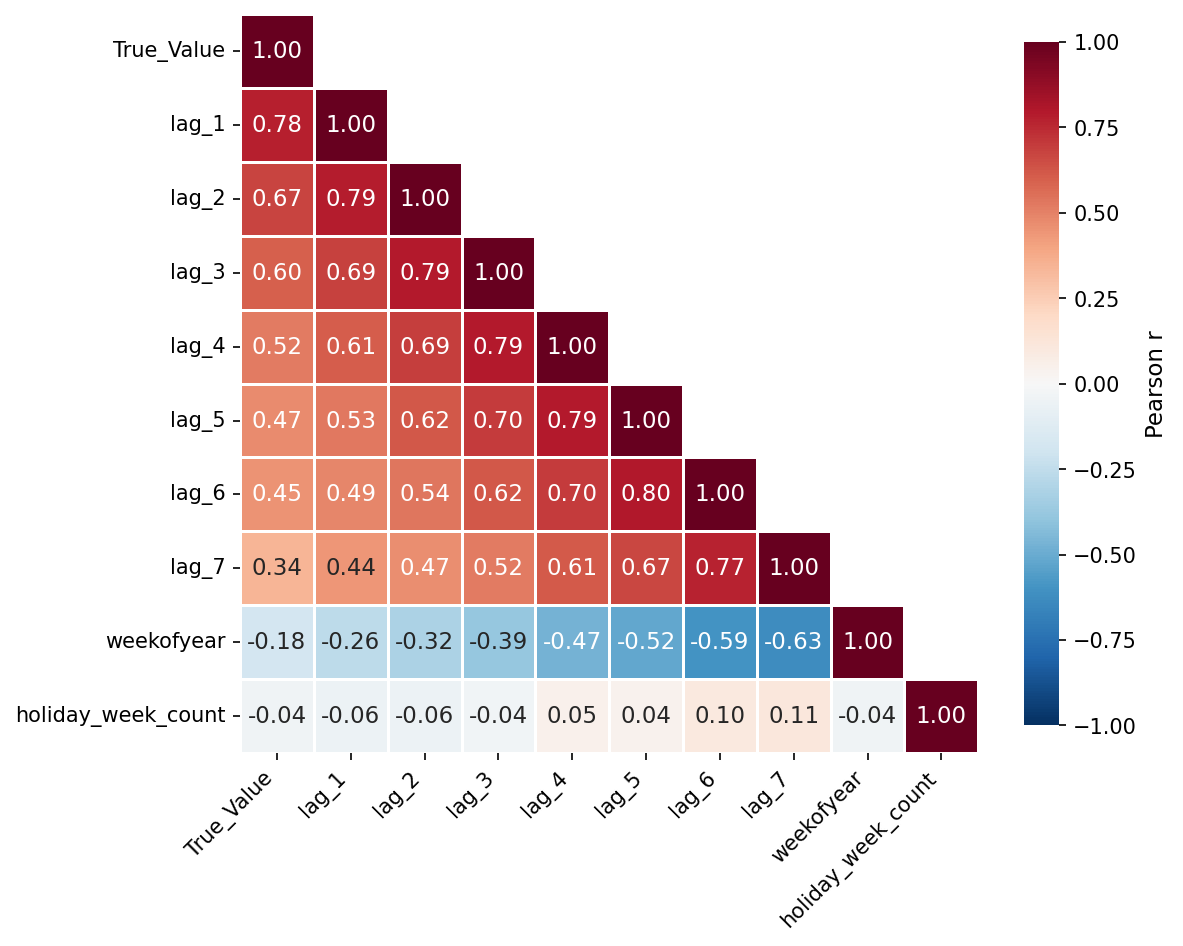

In [9]:
corr_cols = ['True_Value'] + feature_cols
corr = w[corr_cols].corr()

fig, ax = plt.subplots(figsize=(8, 7))

mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
    vmin=-1, vmax=1, square=True, linewidths=0.5,
    cbar_kws={'shrink': 0.8, 'label': 'Pearson r'},
    ax=ax
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
fig.savefig(FIG_DIR / 'fig_4_3_correlation_heatmap.pdf', bbox_inches='tight')
plt.show()

## 6. Figure 4.4 — Seasonal decomposition

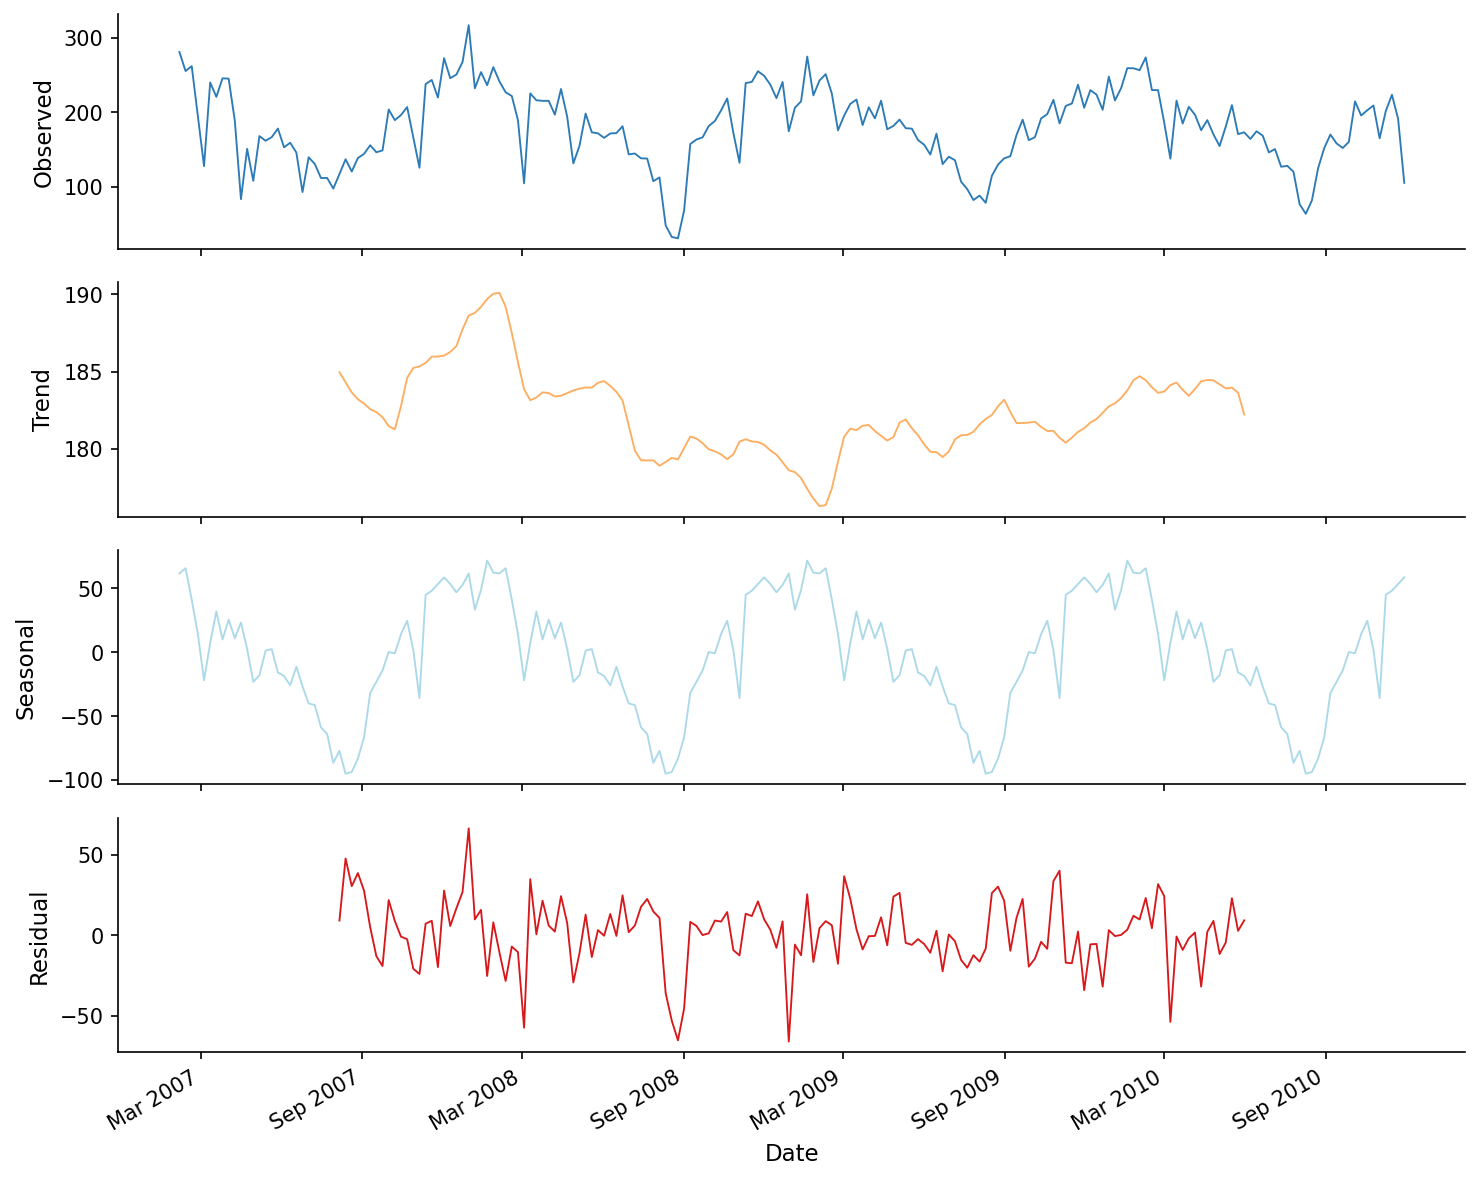

In [10]:
# Set DateTime as index for decomposition
ts = w.set_index('DateTime')['True_Value']
ts.index.freq = pd.infer_freq(ts.index)

decomp = seasonal_decompose(ts, model='additive', period=52)

fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)

components = [
    ('Observed', decomp.observed, '#2c7bb6'),
    ('Trend', decomp.trend, '#fdae61'),
    ('Seasonal', decomp.seasonal, '#abd9e9'),
    ('Residual', decomp.resid, '#d7191c'),
]

for ax, (title, data, color) in zip(axes, components):
    ax.plot(data, color=color, linewidth=0.9)
    ax.set_ylabel(title)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes[-1].set_xlabel('Date')
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[-1].xaxis.set_major_locator(mdates.MonthLocator(interval=6))
fig.autofmt_xdate(rotation=30)

plt.tight_layout()
fig.savefig(FIG_DIR / 'fig_4_4_seasonal_decomposition.pdf', bbox_inches='tight')
plt.show()

## 7. Figure 4.5 — ACF and PACF

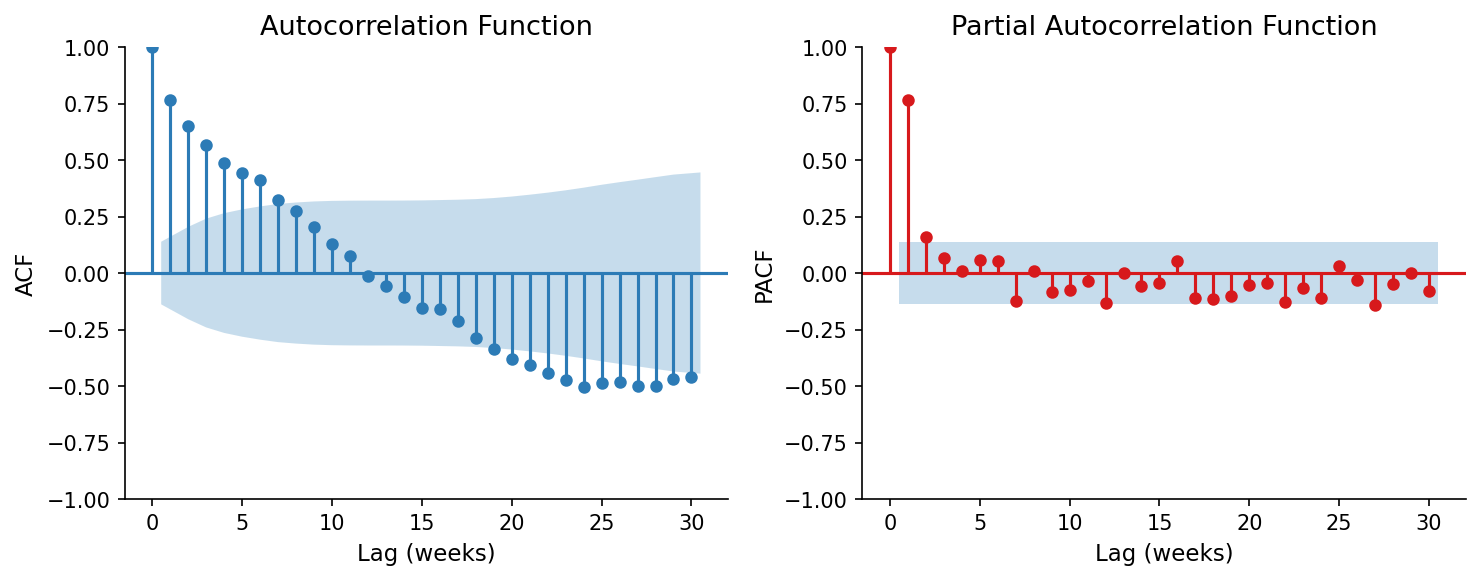

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

plot_acf(ts, lags=30, ax=ax1, color='#2c7bb6', vlines_kwargs={'color': '#2c7bb6'})
ax1.set_xlabel('Lag (weeks)')
ax1.set_ylabel('ACF')
ax1.set_title('Autocorrelation Function')

plot_pacf(ts, lags=30, ax=ax2, color='#d7191c', vlines_kwargs={'color': '#d7191c'}, method='ywm')
ax2.set_xlabel('Lag (weeks)')
ax2.set_ylabel('PACF')
ax2.set_title('Partial Autocorrelation Function')

for ax in (ax1, ax2):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
fig.savefig(FIG_DIR / 'fig_4_5_acf_pacf.pdf', bbox_inches='tight')
plt.show()

## 8. Stationarity test (Augmented Dickey-Fuller)

In [12]:
adf_result = adfuller(ts, autolag='AIC')

print('Augmented Dickey-Fuller Test')
print(f'  Test statistic: {adf_result[0]:.4f}')
print(f'  p-value:        {adf_result[1]:.4f}')
print(f'  Lags used:      {adf_result[2]}')
print(f'  Observations:   {adf_result[3]}')
print('  Critical values:')
for key, val in adf_result[4].items():
    print(f'    {key}: {val:.4f}')

if adf_result[1] < 0.05:
    print('\n=> Reject H0: series is stationary (p < 0.05)')
else:
    print('\n=> Fail to reject H0: series is non-stationary (p >= 0.05)')

Augmented Dickey-Fuller Test
  Test statistic: -4.1264
  p-value:        0.0009
  Lags used:      1
  Observations:   198
  Critical values:
    1%: -3.4638
    5%: -2.8763
    10%: -2.5746

=> Reject H0: series is stationary (p < 0.05)


## 9. Figure 4.6 — Box plot (outlier analysis)

Outliers (IQR method): 2 out of 200 observations
  DateTime  True_Value
2008-08-18   32.314133
2008-08-25   30.520700


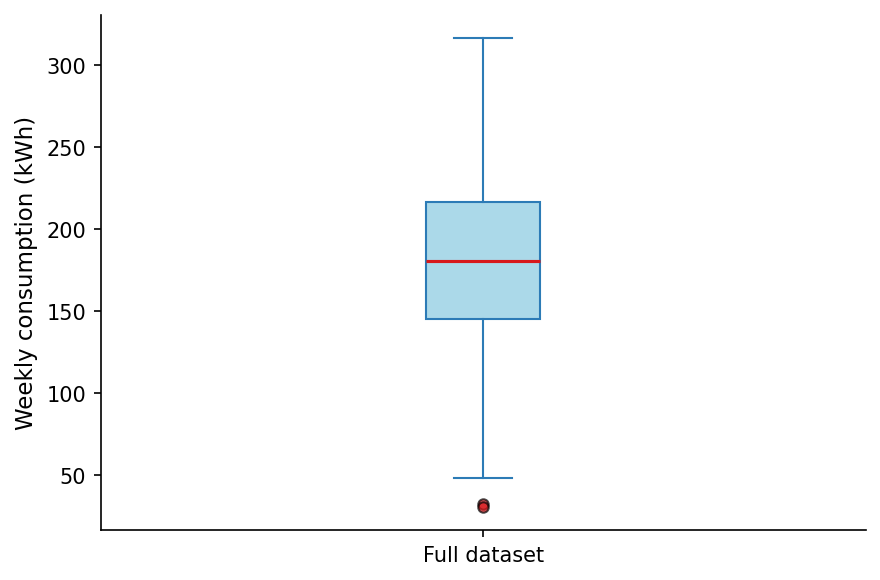

In [13]:
fig, ax = plt.subplots(figsize=(6, 4))

bp = ax.boxplot(w['True_Value'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='#abd9e9', edgecolor='#2c7bb6'),
                medianprops=dict(color='#d7191c', linewidth=1.5),
                whiskerprops=dict(color='#2c7bb6'),
                capprops=dict(color='#2c7bb6'),
                flierprops=dict(marker='o', markerfacecolor='#d7191c', markersize=5, alpha=0.7))
ax.set_ylabel('Weekly consumption (kWh)')
ax.set_xticklabels(['Full dataset'])

# Count outliers (IQR method)
Q1 = w['True_Value'].quantile(0.25)
Q3 = w['True_Value'].quantile(0.75)
IQR = Q3 - Q1
outliers = w[(w['True_Value'] < Q1 - 1.5 * IQR) | (w['True_Value'] > Q3 + 1.5 * IQR)]
print(f'Outliers (IQR method): {len(outliers)} out of {len(w)} observations')
if len(outliers) > 0:
    print(outliers[['DateTime', 'True_Value']].to_string(index=False))

plt.tight_layout()
fig.savefig(FIG_DIR / 'fig_4_6_boxplot.pdf', bbox_inches='tight')
plt.show()

## 10. Save processed data for other notebooks

In [14]:
# Save full weekly dataset
w.to_csv(Path('../../data/weekly_consumption.csv'), index=False)
train.to_csv(Path('../../data/train.csv'), index=False)
test.to_csv(Path('../../data/test.csv'), index=False)
print(f'Saved: weekly_consumption.csv ({len(w)} rows), train.csv ({len(train)} rows), test.csv ({len(test)} rows)')

Saved: weekly_consumption.csv (200 rows), train.csv (140 rows), test.csv (60 rows)
